In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import xgboost as xgb
from itables import init_notebook_mode, show

os.chdir('C:/Users/lhcse/iCloudDrive/Learnings/Power-price-forecast')
df = pd.read_parquet('data/processed/features.parquet')

#4.1 Define features and taget

In [24]:
feature_cols = [
    'wind_on_error_lag24', 'wind_off_error_lag24',
    'solar_error_lag24', 'load_error_lag24',
    'ren_load_ratio_fc', 'ren_surplus_fc',
    'net_export_lag24',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_peak',
    'price_lag_24h', 'price_lag_48h', 'price_lag_168h',
    'price_roll_7d_mean', 'price_roll_7d_std'
]
target_col = 'price_eur_mwh'

#4.2 Time-based train/test split

In [25]:
TRAIN_END  = '2023-06-30'
TEST_START = '2023-07-01'

train = df.loc[:TRAIN_END]
test  = df.loc[TEST_START:]

X_train, y_train = train[feature_cols], train[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {len(X_train):,} hours ({TRAIN_END[:4]} cutoff)")
print(f"Test:  {len(X_test):,} hours")

Train: 30,453 hours (2023 cutoff)
Test:  13,199 hours


#4.3 Naive benchmark

In [26]:
y_bench = test['price_lag_168h']  # same hour, one week ago

mae_bench  = mean_absolute_error(y_test, y_bench)
rmse_bench = root_mean_squared_error(y_test, y_bench)
print(f"Benchmark — MAE: {mae_bench:.2f} €/MWh | RMSE: {rmse_bench:.2f} €/MWh")

Benchmark — MAE: 32.88 €/MWh | RMSE: 52.99 €/MWh


#4.4 LASSO

In [27]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  LassoCV(cv=5, max_iter=10000, random_state=42))
])

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)
print(f"LASSO  — MAE: {mae_lasso:.2f} €/MWh | RMSE: {rmse_lasso:.2f} €/MWh")

coefs = pd.Series(
    lasso.named_steps['lasso'].coef_,
    index=feature_cols
).sort_values(key=abs, ascending=False)

print("\nLASSO coefficients (non-zero only):")
print(coefs[coefs != 0].round(3))

LASSO  — MAE: 25.46 €/MWh | RMSE: 35.99 €/MWh

LASSO coefficients (non-zero only):
price_lag_24h           69.218
ren_load_ratio_fc      -28.252
price_lag_168h          16.865
price_roll_7d_mean      13.998
net_export_lag24        11.905
price_roll_7d_std        8.594
is_weekend              -7.111
hour_cos                -6.454
month_cos               -6.370
month_sin                2.114
is_peak                  1.948
wind_off_error_lag24    -1.782
hour_sin                -1.573
price_lag_48h            0.984
wind_on_error_lag24     -0.967
load_error_lag24        -0.801
ren_surplus_fc          -0.374
solar_error_lag24       -0.226
dtype: float64


#4.5 XGBoost

In [28]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
print(f"XGBoost — MAE: {mae_xgb:.2f} €/MWh | RMSE: {rmse_xgb:.2f} €/MWh")

[0]	validation_0-rmse:61.37032
[100]	validation_0-rmse:26.78979
[200]	validation_0-rmse:26.54566
[254]	validation_0-rmse:26.56301
XGBoost — MAE: 16.58 €/MWh | RMSE: 26.53 €/MWh


#4.6 Feature importance

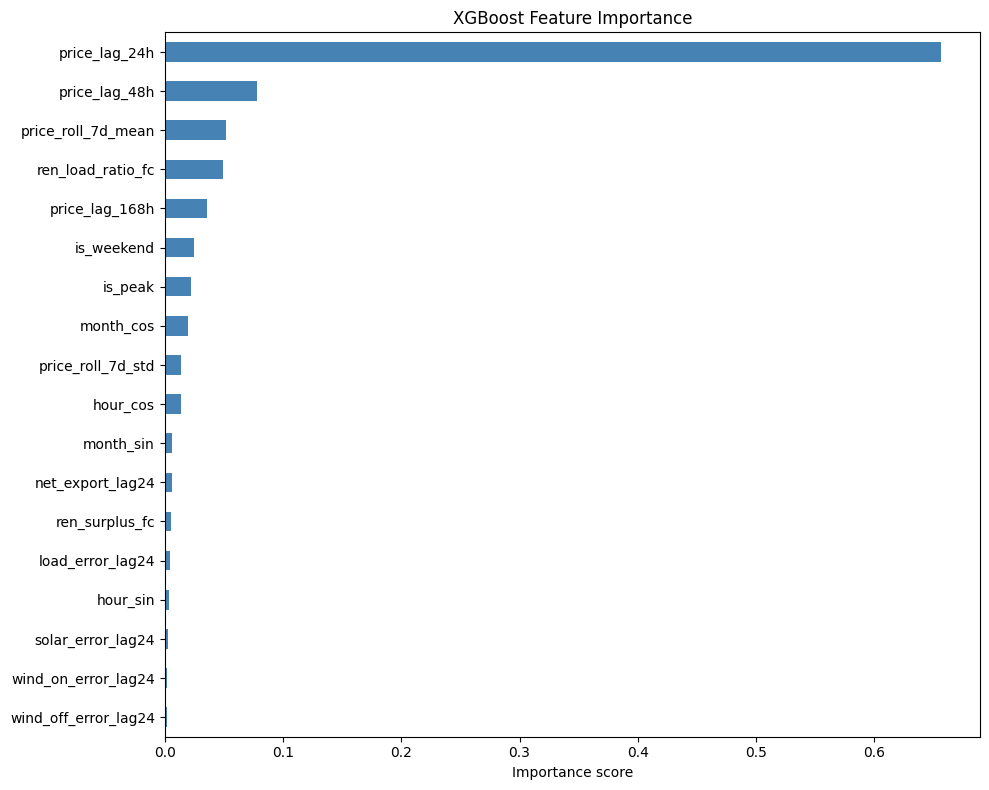

In [29]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', dpi=150)
plt.show()

#4.7 Hyperparameter Tuning with optuna

In [30]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose output

# ── Optuna tuning for XGBoost ──────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':           trial.suggest_int('max_depth', 3, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':           trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':    trial.suggest_int('min_child_weight', 1, 10),
        'gamma':               trial.suggest_float('gamma', 0.0, 1.0),
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    return mean_absolute_error(y_test, model.predict(X_test))

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42)
)
study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest XGBoost MAE:    {study_xgb.best_value:.2f} €/MWh")
print(f"Best XGBoost params: {study_xgb.best_params}")

Best trial: 71. Best value: 16.3149: 100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


Best XGBoost MAE:    16.31 €/MWh
Best XGBoost params: {'n_estimators': 966, 'max_depth': 6, 'learning_rate': 0.018769849193417187, 'subsample': 0.8478955511416241, 'colsample_bytree': 0.7707320552329116, 'min_child_weight': 2, 'gamma': 0.22680357715485808}


#4.8 Random forrest

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features=0.8,
    n_jobs=-1,          # use all CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest — MAE: {mae_rf:.2f} €/MWh | RMSE: {rmse_rf:.2f} €/MWh")

Random Forest — MAE: 18.07 €/MWh | RMSE: 29.10 €/MWh


#4.9 Hyper parameter tuning with optuna

In [32]:
# ── Optuna tuning for Random Forest ───────────────────────────────────────
def rf_objective(trial):
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':      trial.suggest_int('max_depth', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':   trial.suggest_float('max_features', 0.4, 1.0),
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    return mean_absolute_error(y_test, model.predict(X_test))

study_rf = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42)
)
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest RF MAE:    {study_rf.best_value:.2f} €/MWh")
print(f"Best RF params: {study_rf.best_params}")

Best trial: 35. Best value: 17.0431: 100%|██████████| 50/50 [2:31:45<00:00, 182.10s/it]   


Best RF MAE:    17.04 €/MWh
Best RF params: {'n_estimators': 855, 'max_depth': 21, 'min_samples_leaf': 7, 'max_features': 0.4001196740412724}


#4.10 Retrain models with best Params

In [36]:
# ── Retrain final models with best params ─────────────────────────────────
xgb_tuned = xgb.XGBRegressor(
    **study_xgb.best_params,
    random_state=42,
    eval_metric='mae'
)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

rf_tuned = RandomForestRegressor(
    **study_rf.best_params,
    n_jobs=-1,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)

print(f"XGBoost (default) MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"XGBoost (tuned)   MAE: {mean_absolute_error(y_test, y_pred_xgb_tuned):.2f}")
print(f"RF      (default) MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RF      (tuned)   MAE: {mean_absolute_error(y_test, y_pred_rf_tuned):.2f}")

XGBoost (default) MAE: 16.58
XGBoost (tuned)   MAE: 16.33
RF      (default) MAE: 18.07
RF      (tuned)   MAE: 17.08


#4.11 Regime-split evaluation

In [34]:
# ── Regime evaluation with tuned models ───────────────────────────────────
results_tuned = pd.DataFrame({
    'actual':     y_test,
    'bench':      y_bench.values,
    'lasso':      y_pred_lasso,
    'rf':         y_pred_rf_tuned,
    'xgb':        y_pred_xgb_tuned,
}, index=y_test.index)

results_tuned['regime'] = 'normal'
results_tuned.loc[results_tuned['actual'] < 0, 'regime'] = 'negative'
results_tuned.loc[results_tuned['actual'] > results_tuned['actual'].quantile(0.95),
                  'regime'] = 'spike'

print(f"\n{'Regime':10s} {'N':>6s}  {'Benchmark':>10s}  {'LASSO':>7s}  {'RF':>7s}  {'XGBoost':>9s}")
print("─" * 60)

for regime in ['normal', 'negative', 'spike']:
    sub = results_tuned[results_tuned['regime'] == regime]
    if len(sub) == 0:
        continue
    mae_b = mean_absolute_error(sub['actual'], sub['bench'])
    mae_l = mean_absolute_error(sub['actual'], sub['lasso'])
    mae_r = mean_absolute_error(sub['actual'], sub['rf'])
    mae_x = mean_absolute_error(sub['actual'], sub['xgb'])
    print(f"{regime:10s} {len(sub):>6,}  {mae_b:>10.2f}  {mae_l:>7.2f}  {mae_r:>7.2f}  {mae_x:>9.2f}")


Regime          N   Benchmark    LASSO       RF    XGBoost
────────────────────────────────────────────────────────────
normal     11,868       29.66    23.24    15.22      14.51
negative      671       50.93    33.94    18.14      17.81
spike         660       72.47    56.79    49.47      47.59


#4.12 Plot our predictions vs actual

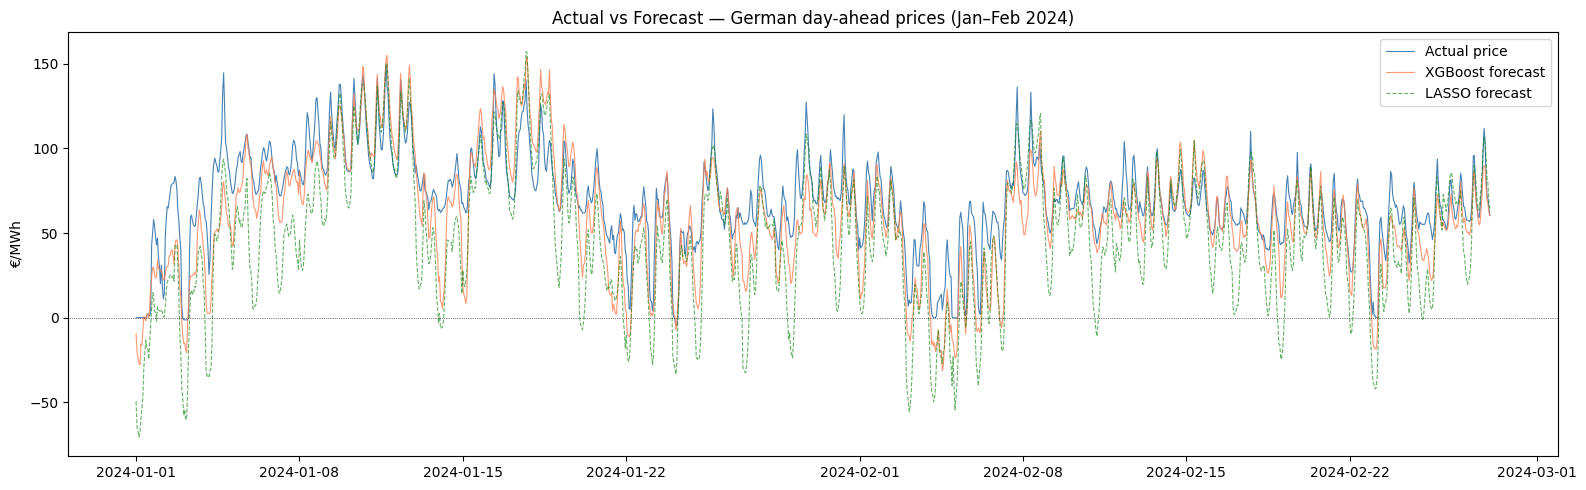

In [37]:
# Pick a readable window — 2 months of test data
plot_start = '2024-01-01'
plot_end   = '2024-02-28'

mask = (results_tuned.index >= plot_start) & (results_tuned.index <= plot_end)
sub  = results_tuned.loc[mask]

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(sub.index, sub['actual'], color='steelblue',
        linewidth=0.8, label='Actual price')
ax.plot(sub.index, sub['xgb'],    color='coral',
        linewidth=0.8, alpha=0.8, label='XGBoost forecast')
ax.plot(sub.index, sub['lasso'],  color='green',
        linewidth=0.8, alpha=0.6, linestyle='--', label='LASSO forecast')
ax.axhline(0, color='black', linestyle=':', linewidth=0.5)

ax.set_title('Actual vs Forecast — German day-ahead prices (Jan–Feb 2024)')
ax.set_ylabel('€/MWh')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/forecast_vs_actual.png', dpi=150)
plt.show()